# Lecture 2 (Part 1), Notebook 03: Deep kernel learning — a neural feature extractor with a GP head

**Course:** CEMRACS 2026 Summer School — Modeling and AI for Environmental Transition · Lecture 2 (July 15, 2026, CIRM, Marseille)  
**Script reference:** §9.7 (Deep kernel learning — neural feature extractor + GP head on a hidden-regime problem)  
**Notebook role:** core  
**Author:** Simon Scheidegger (HEC Lausanne · Grantham Research Institute, LSE)
---

In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0

## Overview

This notebook introduces **deep kernels** step by step.

The organizing idea is simple:

1. A plain Gaussian process (GP) assumes that **distance in the raw input space** is already meaningful.
2. A **deep kernel** first learns a feature map $\phi_\theta(x)$ with a neural network.
3. A GP is then applied to the learned representation instead of to the raw input:
   $$
   k_{\text{DKL}}(x, x') \;=\; k_{\text{base}}\!\left(\phi_\theta(x),\,\phi_\theta(x')\right).
   $$

This notebook is intentionally pedagogical:

- We begin with a **warm-up** where a standard GP is already enough.
- We then construct a **hidden-regime regression problem** where raw stationary kernels struggle.
- We show how a **feature map that repairs the geometry** helps the GP.
- Finally, we train a **small neural network to learn that feature map** and benchmark the resulting learned-feature GP against standard **RBF** and **Matern** GPs.

### Important teaching note

To keep the notebook transparent and fast, the feature-learning section uses a **supervised proxy target** for the latent coordinate. In production DKL, one would typically learn the feature extractor and GP **jointly** via the GP marginal likelihood (for example with GPyTorch). The present notebook focuses on the core geometry and benchmarking intuition.

> **Implementation note.** This notebook implements DKL via a supervised feature extractor + sklearn GP head, not joint marginal-likelihood training with GPyTorch. The conceptual workflow is identical; the joint-likelihood version is left as an extension.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as ConstantKernel
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

SEED = 0
NOISE_STD = 0.05

np.random.seed(SEED)
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def gaussian_nlpd(y_true, mean, std):
    var = np.maximum(std**2, 1e-8)
    return float(0.5 * np.mean(np.log(2 * np.pi * var) + (y_true - mean) ** 2 / var))

def coverage_95(y_true, mean, std):
    return float(np.mean((y_true >= mean - 1.96 * std) & (y_true <= mean + 1.96 * std)))

def observation_std(latent_std, noise_std=NOISE_STD):
    # sklearn returns latent-function uncertainty; for predictive intervals we add observation noise back in.
    return np.sqrt(latent_std**2 + noise_std**2)

print('Imports successful.')
print(f'PyTorch version: {torch.__version__}')


In [ ]:
# Hyperparameter budget, dispatched on RUN_MODE (see the run-mode cell above).
if RUN_MODE == "smoke":
    DKL_EPOCHS, DKL_BATCH = 200, 64
elif RUN_MODE == "teaching":
    DKL_EPOCHS, DKL_BATCH = 800, 128
elif RUN_MODE == "production":
    DKL_EPOCHS, DKL_BATCH = 3_000, 256
else:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}")



## 1. Warm-up: When a Plain GP Is Already Enough

Before adding neural feature maps, it is useful to see the case where a standard GP is already the right tool.

We generate a smooth one-dimensional function,
$$
f(x) = \sin(x) + 0.2x,
$$
and fit a standard **RBF GP**.

This is exactly the kind of problem where a plain GP shines:

- the input is already low-dimensional,
- the geometry is simple,
- the target is smooth,
- and uncertainty quantification comes for free.

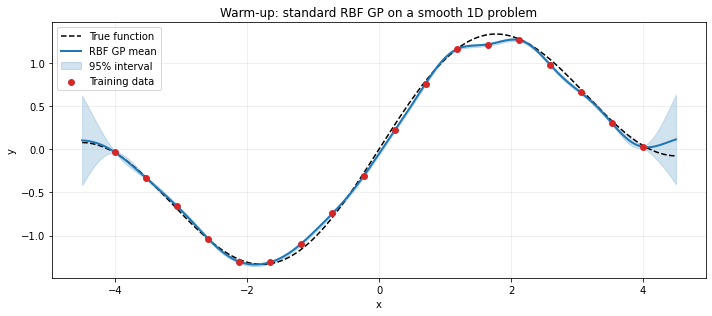

Warm-up RMSE: 0.0505


In [2]:

X_train_1d = np.linspace(-4.0, 4.0, 18).reshape(-1, 1)
y_train_1d = np.sin(X_train_1d[:, 0]) + 0.2 * X_train_1d[:, 0] + rng.normal(scale=0.05, size=len(X_train_1d))

X_test_1d = np.linspace(-4.5, 4.5, 300).reshape(-1, 1)
y_true_1d = np.sin(X_test_1d[:, 0]) + 0.2 * X_test_1d[:, 0]

rbf_1d = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)),
    alpha=1e-4,
    normalize_y=True,
    n_restarts_optimizer=3,
    random_state=SEED,
)
rbf_1d.fit(X_train_1d, y_train_1d)
mean_1d, std_1d = rbf_1d.predict(X_test_1d, return_std=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(X_test_1d[:, 0], y_true_1d, color='black', linestyle='--', linewidth=1.5, label='True function')
ax.plot(X_test_1d[:, 0], mean_1d, color='tab:blue', linewidth=2.0, label='RBF GP mean')
ax.fill_between(
    X_test_1d[:, 0],
    mean_1d - 1.96 * std_1d,
    mean_1d + 1.96 * std_1d,
    color='tab:blue',
    alpha=0.2,
    label='95% interval',
)
ax.scatter(X_train_1d[:, 0], y_train_1d, color='tab:red', s=35, zorder=5, label='Training data')
ax.set_title('Warm-up: standard RBF GP on a smooth 1D problem')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f'Warm-up RMSE: {rmse(y_true_1d, mean_1d):.4f}')



The warm-up already suggests the right philosophy:

- **Do not use deep kernels by default.**
- Use them when the *raw input geometry is the bottleneck*, not when a plain GP already works.

We now build a synthetic example where the raw geometry is the bottleneck.


## 2. A Hidden-Regime Problem Where Raw Stationary Kernels Struggle

We now create a two-dimensional dataset with a **hidden phase shift**.

Let
$$
 u(x_0, x_1) = x_0 + 2 \cdot \mathbf{1}\{x_1 \ge 0\},
$$
and define the regression target as
$$
 y = \sin(u) + 0.2\,u + \varepsilon.
$$

### Why this is interesting

- In the latent coordinate $u$, the function is **smooth and easy**.
- In the raw coordinates $(x_0, x_1)$, crossing the boundary $x_1 = 0$ causes a **regime-dependent phase shift**.
- A stationary raw-input kernel such as **RBF** or **Matern** tends to blur information across that boundary.

This is the exact situation where a deep kernel can help: the neural network learns a representation in which the GP sees a smoother problem.

In [3]:
N_TRAIN = 120
N_TEST = 400

X_train = rng.uniform(-2.5, 2.5, size=(N_TRAIN, 2))
X_test = rng.uniform(-2.5, 2.5, size=(N_TEST, 2))

def latent_u(X):
    x0 = X[:, 0]
    x1 = X[:, 1]
    return x0 + 2.0 * (x1 >= 0.0)

def target_function(X):
    u = latent_u(X)
    return np.sin(u) + 0.2 * u

def teacher_feature(X):
    return (X[:, 0] + 2.0 / (1.0 + np.exp(-8.0 * X[:, 1]))).reshape(-1, 1)

# The observed targets are noisy, while the test targets below stay noise-free so we can judge mean prediction cleanly.
y_train = target_function(X_train) + rng.normal(scale=NOISE_STD, size=N_TRAIN)
y_test = target_function(X_test)

x0_grid = np.linspace(-2.5, 2.5, 120)
x1_grid = np.linspace(-2.5, 2.5, 120)
X0, X1 = np.meshgrid(x0_grid, x1_grid)
X_grid = np.column_stack([X0.ravel(), X1.ravel()])
y_true_grid = target_function(X_grid).reshape(X0.shape)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)
print(f'Target range: [{y_train.min():.3f}, {y_train.max():.3f}]')


Training set shape: (120, 2)
Test set shape: (400, 2)
Target range: [-1.271, 1.422]


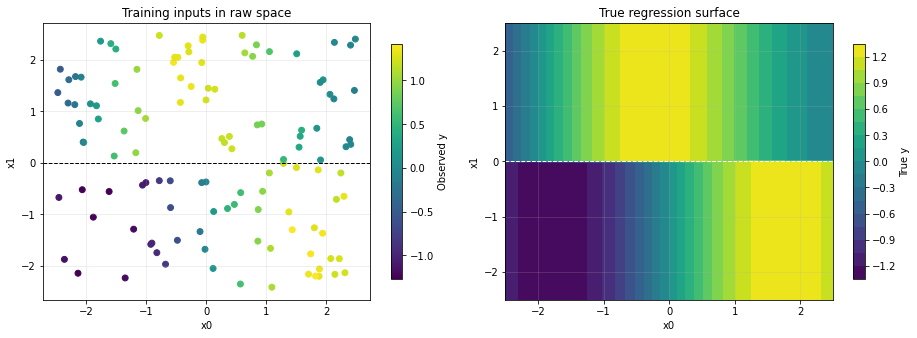

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sc = axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', s=35)
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Training inputs in raw space')
axes[0].set_xlabel('x0')
axes[0].set_ylabel('x1')
plt.colorbar(sc, ax=axes[0], shrink=0.85, label='Observed y')

cont = axes[1].contourf(X0, X1, y_true_grid, levels=25, cmap='viridis')
axes[1].axhline(0.0, color='white', linestyle='--', linewidth=1.0)
axes[1].set_title('True regression surface')
axes[1].set_xlabel('x0')
axes[1].set_ylabel('x1')
plt.colorbar(cont, ax=axes[1], shrink=0.85, label='True y')

plt.tight_layout()
plt.show()



## 3. Raw-Input GP Baselines

We now fit two standard GP regressors directly on the raw input pair $(x_0, x_1)$:

- **RBF GP** (squared exponential / Gaussian kernel)
- **Matern GP** with $
u = 3/2$

Both models are given the same standardized inputs and allowed to learn their hyperparameters via marginal likelihood.

In [5]:
x_scaler = StandardScaler().fit(X_train)
X_train_std = x_scaler.transform(X_train)
X_test_std = x_scaler.transform(X_test)
X_grid_std = x_scaler.transform(X_grid)

raw_models = {
    'RBF GP': GaussianProcessRegressor(
        kernel=ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=np.ones(2), length_scale_bounds=(1e-2, 1e2)),
        alpha=1e-4,
        normalize_y=True,
        n_restarts_optimizer=3,
        random_state=SEED,
    ),
    'Matern GP': GaussianProcessRegressor(
        kernel=ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale=np.ones(2), length_scale_bounds=(1e-2, 1e2), nu=1.5),
        alpha=1e-4,
        normalize_y=True,
        n_restarts_optimizer=3,
        random_state=SEED,
    ),
}

results = []
model_store = {}

for name, model in raw_models.items():
    model.fit(X_train_std, y_train)
    mean_test, std_test = model.predict(X_test_std, return_std=True)
    mean_grid, std_grid = model.predict(X_grid_std, return_std=True)
    obs_std_test = observation_std(std_test)

    results.append({
        'Model': name,
        'RMSE': rmse(y_test, mean_test),
        'ObsNLPD': gaussian_nlpd(y_test, mean_test, obs_std_test),
        'ObsCoverage95': coverage_95(y_test, mean_test, obs_std_test),
    })
    model_store[name] = {
        'model': model,
        'mean_test': mean_test,
        'std_test': std_test,
        'obs_std_test': obs_std_test,
        'mean_grid': mean_grid.reshape(X0.shape),
        'std_grid': std_grid.reshape(X0.shape),
    }
    print(name)
    print('  learned kernel:', model.kernel_)
    print(f"  RMSE        = {results[-1]['RMSE']:.4f}")
    print(f"  Obs. NLPD   = {results[-1]['ObsNLPD']:.4f}")
    print(f"  Obs. 95% cov= {results[-1]['ObsCoverage95']:.3f}")


RBF GP
  learned kernel: 0.907**2 * RBF(length_scale=[0.545, 0.121])
  RMSE        = 0.3720
  Obs. NLPD   = 0.1840
  Obs. 95% cov= 0.880


Matern GP
  learned kernel: 1.09**2 * Matern(length_scale=[1.46, 0.392], nu=1.5)
  RMSE        = 0.1414
  Obs. NLPD   = -0.6784
  Obs. 95% cov= 0.968


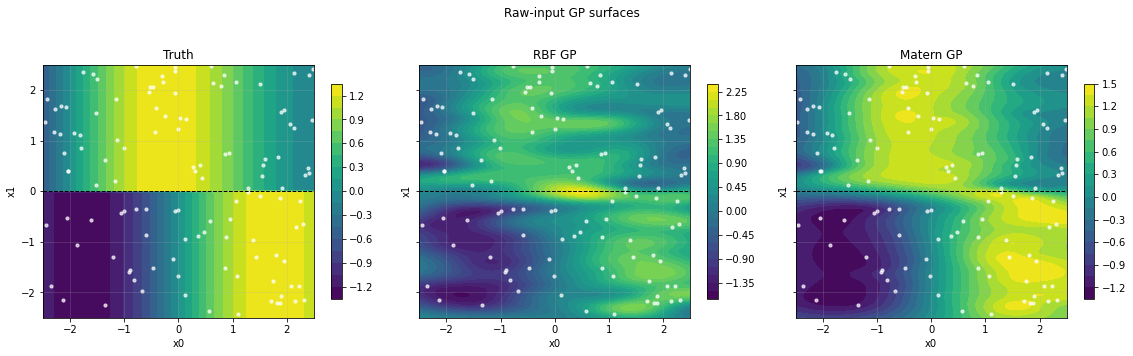

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)

panels = [
    ('Truth', y_true_grid),
    ('RBF GP', model_store['RBF GP']['mean_grid']),
    ('Matern GP', model_store['Matern GP']['mean_grid']),
]

for ax, (title, surface) in zip(axes, panels):
    contour = ax.contourf(X0, X1, surface, levels=25, cmap='viridis')
    ax.scatter(X_train[:, 0], X_train[:, 1], c='white', s=10, alpha=0.7)
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel('x0')
    ax.set_ylabel('x1')
    plt.colorbar(contour, ax=ax, shrink=0.85)

plt.suptitle('Raw-input GP surfaces', y=1.02)
plt.tight_layout()
plt.show()



Even before introducing the deep kernel, the failure mode is visible:

- both raw-input GPs are trying to use a **single stationary metric** in $(x_0, x_1)$,
- so they blur across the hidden boundary,
- and the phase shift is not represented as cleanly as it should be.

The next step is to change the geometry seen by the GP.


## 4. A Teacher Deep Kernel

To make the geometry explicit, define the smooth feature map
$$
\phi_{\text{teacher}}(x_0, x_1) \;=\; x_0 + 2\,\sigma(8 x_1),
$$
where $\sigma(z) = \dfrac{1}{1 + e^{-z}}$ is the logistic sigmoid.

This feature map does exactly what we want:

- when $x_1 < 0$, it leaves the coordinate close to $x_0$,
- when $x_1 > 0$, it shifts the coordinate by roughly $+2$,
- so the latent smooth target becomes much easier for a 1D GP.

We now fit a GP on $\phi_{\text{teacher}}(x)$ instead of on the raw pair $(x_0, x_1)$.

In [7]:
teacher_train = teacher_feature(X_train)
teacher_test = teacher_feature(X_test)
teacher_grid = teacher_feature(X_grid)

teacher_scaler = StandardScaler().fit(teacher_train)
teacher_train_std = teacher_scaler.transform(teacher_train)
teacher_test_std = teacher_scaler.transform(teacher_test)
teacher_grid_std = teacher_scaler.transform(teacher_grid)

teacher_gp = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)),
    alpha=0.01,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=SEED,
)
teacher_gp.fit(teacher_train_std, y_train)
teacher_mean_test, teacher_std_test = teacher_gp.predict(teacher_test_std, return_std=True)
teacher_mean_grid, teacher_std_grid = teacher_gp.predict(teacher_grid_std, return_std=True)
teacher_obs_std_test = observation_std(teacher_std_test)

results.append({
    'Model': 'Teacher deep-kernel GP',
    'RMSE': rmse(y_test, teacher_mean_test),
    'ObsNLPD': gaussian_nlpd(y_test, teacher_mean_test, teacher_obs_std_test),
    'ObsCoverage95': coverage_95(y_test, teacher_mean_test, teacher_obs_std_test),
})
model_store['Teacher deep-kernel GP'] = {
    'model': teacher_gp,
    'mean_test': teacher_mean_test,
    'std_test': teacher_std_test,
    'obs_std_test': teacher_obs_std_test,
    'mean_grid': teacher_mean_grid.reshape(X0.shape),
    'std_grid': teacher_std_grid.reshape(X0.shape),
}

print('Teacher deep-kernel GP')
print('  learned top kernel:', teacher_gp.kernel_)
print(f"  RMSE        = {results[-1]['RMSE']:.4f}")
print(f"  Obs. NLPD   = {results[-1]['ObsNLPD']:.4f}")
print(f"  Obs. 95% cov= {results[-1]['ObsCoverage95']:.3f}")


Teacher deep-kernel GP
  learned top kernel: 1.36**2 * RBF(length_scale=1.2)
  RMSE        = 0.1180
  Obs. NLPD   = 0.4891
  Obs. 95% cov= 0.902


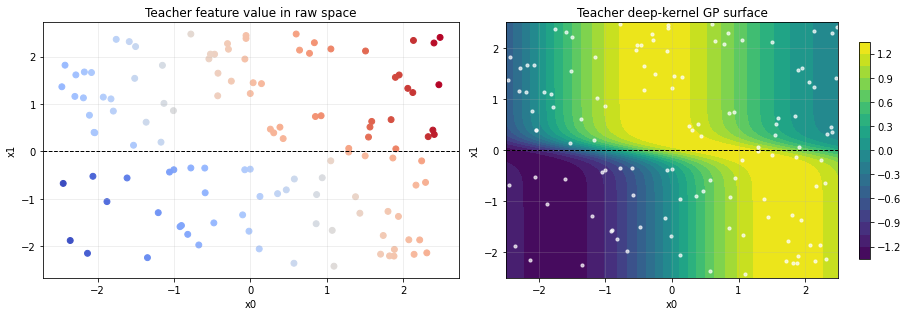

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(X_train[:, 0], X_train[:, 1], c=teacher_train[:, 0], cmap='coolwarm', s=35)
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Teacher feature value in raw space')
axes[0].set_xlabel('x0')
axes[0].set_ylabel('x1')

contour = axes[1].contourf(X0, X1, model_store['Teacher deep-kernel GP']['mean_grid'], levels=25, cmap='viridis')
axes[1].scatter(X_train[:, 0], X_train[:, 1], c='white', s=10, alpha=0.7)
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1].set_title('Teacher deep-kernel GP surface')
axes[1].set_xlabel('x0')
axes[1].set_ylabel('x1')
plt.colorbar(contour, ax=axes[1], shrink=0.85)

plt.tight_layout()
plt.show()



This is the deep-kernel idea in its cleanest form:

- the GP itself is still just a GP,
- the gain comes from **changing the input representation**,
- and once the representation is good, even a simple 1D RBF kernel performs very well.

Next we replace the teacher feature map by a **learned** neural approximation.

## 5. Learn the Feature Map with a Small Neural Network

To keep the notebook fully transparent, we train a small neural network to approximate the teacher feature
$$
\phi_{\text{teacher}}(x).
$$

This is a pedagogical proxy for deep kernel learning:

- the network learns a **task-relevant representation**,
- the GP is placed on that representation,
- and the benchmark can then be compared directly to raw RBF and Matern GPs.

We still report GP-based observation intervals, but there is an important caveat:

- because the feature extractor is trained in a separate first stage here,
- uncertainty calibration is not as strong as in a fully joint DKL fit,
- so the cleanest performance comparison in this notebook is the **mean-prediction gain** and the **regime-recovery plots**.

In a production DKL setup, one would replace this supervised feature-matching step with **joint optimization of feature extractor + GP marginal likelihood**.

In [ ]:
class FeatureNet(nn.Module):
    # Small neural net mapping raw 2D inputs to a 1D latent feature.
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)

feature_net = FeatureNet()
optimizer = torch.optim.Adam(feature_net.parameters(), lr=0.01, weight_decay=1e-4)

X_train_t = torch.tensor(X_train_std, dtype=torch.float32)
teacher_train_t = torch.tensor(teacher_train_std, dtype=torch.float32)


# Per-batch training step, JIT-compiled with torch.compile (Simon's hard rule).
def feature_step(x, target):
    pred = feature_net(x)
    loss = torch.mean((pred - target) ** 2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss

try:
    feature_step = torch.compile(feature_step)
except Exception as e:
    print(f"torch.compile unavailable ({e}); falling back to eager step.")

loss_history = []
for epoch in range(500):
    loss = feature_step(X_train_t, teacher_train_t)
    loss_history.append(float(loss.item()))

with torch.no_grad():
    learned_train = feature_net(torch.tensor(X_train_std, dtype=torch.float32)).numpy()
    learned_test = feature_net(torch.tensor(X_test_std, dtype=torch.float32)).numpy()
    learned_grid = feature_net(torch.tensor(X_grid_std, dtype=torch.float32)).numpy()

print(f'Final feature-learning loss: {loss_history[-1]:.6f}')


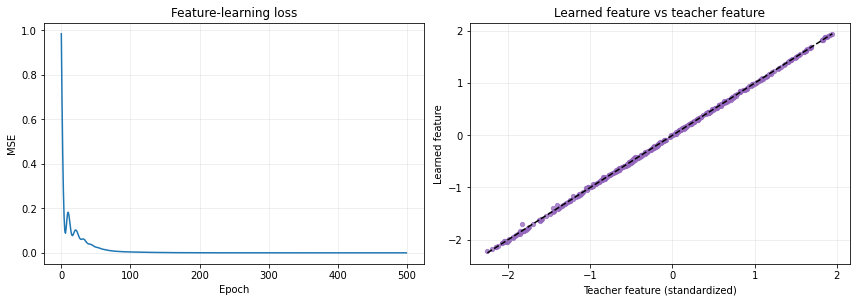

Feature RMSE on the test set: 0.0145


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

axes[0].plot(loss_history, color='tab:blue')
axes[0].set_title('Feature-learning loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')

axes[1].scatter(teacher_test_std[:, 0], learned_test[:, 0], s=18, alpha=0.75, color='tab:purple')
line_min = min(teacher_test_std[:, 0].min(), learned_test[:, 0].min())
line_max = max(teacher_test_std[:, 0].max(), learned_test[:, 0].max())
axes[1].plot([line_min, line_max], [line_min, line_max], color='black', linestyle='--')
axes[1].set_title('Learned feature vs teacher feature')
axes[1].set_xlabel('Teacher feature (standardized)')
axes[1].set_ylabel('Learned feature')

plt.tight_layout()
plt.show()

print(f'Feature RMSE on the test set: {rmse(teacher_test_std[:, 0], learned_test[:, 0]):.4f}')


In [11]:
learned_gp = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)),
    alpha=0.01,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=SEED,
)
learned_gp.fit(learned_train, y_train)
learned_mean_test, learned_std_test = learned_gp.predict(learned_test, return_std=True)
learned_mean_grid, learned_std_grid = learned_gp.predict(learned_grid, return_std=True)
learned_obs_std_test = observation_std(learned_std_test)

results.append({
    'Model': 'Learned-feature GP',
    'RMSE': rmse(y_test, learned_mean_test),
    'ObsNLPD': gaussian_nlpd(y_test, learned_mean_test, learned_obs_std_test),
    'ObsCoverage95': coverage_95(y_test, learned_mean_test, learned_obs_std_test),
})
model_store['Learned-feature GP'] = {
    'model': learned_gp,
    'mean_test': learned_mean_test,
    'std_test': learned_std_test,
    'obs_std_test': learned_obs_std_test,
    'mean_grid': learned_mean_grid.reshape(X0.shape),
    'std_grid': learned_std_grid.reshape(X0.shape),
}

print('Learned-feature GP')
print('  learned top kernel:', learned_gp.kernel_)
print(f"  RMSE        = {results[-1]['RMSE']:.4f}")
print(f"  Obs. NLPD   = {results[-1]['ObsNLPD']:.4f}")
print(f"  Obs. 95% cov= {results[-1]['ObsCoverage95']:.3f}")


Learned-feature GP
  learned top kernel: 1.37**2 * RBF(length_scale=1.21)
  RMSE        = 0.1279
  Obs. NLPD   = 0.9259
  Obs. 95% cov= 0.890


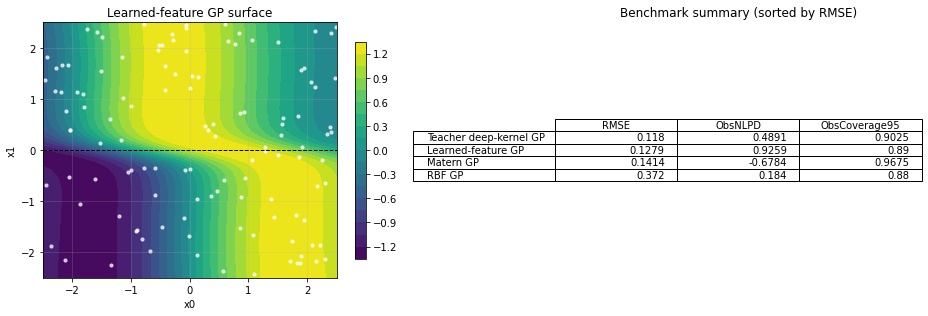

,RMSE,ObsNLPD,ObsCoverage95
Model,,,
Teacher deep-kernel GP,0.1180,0.4891,0.9025
Learned-feature GP,0.1279,0.9259,0.8900
Matern GP,0.1414,-0.6784,0.9675
RBF GP,0.3720,0.1840,0.8800


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

contour = axes[0].contourf(X0, X1, model_store['Learned-feature GP']['mean_grid'], levels=25, cmap='viridis')
axes[0].scatter(X_train[:, 0], X_train[:, 1], c='white', s=10, alpha=0.7)
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Learned-feature GP surface')
axes[0].set_xlabel('x0')
axes[0].set_ylabel('x1')
plt.colorbar(contour, ax=axes[0], shrink=0.85)

comparison = pd.DataFrame(results).set_index('Model').sort_values('RMSE').round(4)
axes[1].axis('off')
axes[1].table(
    cellText=comparison.values,
    rowLabels=comparison.index,
    colLabels=comparison.columns,
    loc='center',
)
axes[1].set_title('Benchmark summary (sorted by RMSE)')

plt.tight_layout()
plt.show()

comparison



## 6. Slice Plots: Where the Deep Kernel Helps

A good way to see the problem is to hold $x_1$ fixed and sweep over $x_0$.

We look at two slices:

- one in the lower regime ($x_1 < 0$),
- one in the upper regime ($x_1 > 0$).

A stationary raw-input GP tries to compromise across both regimes, while the deep-kernel feature map explicitly aligns them.

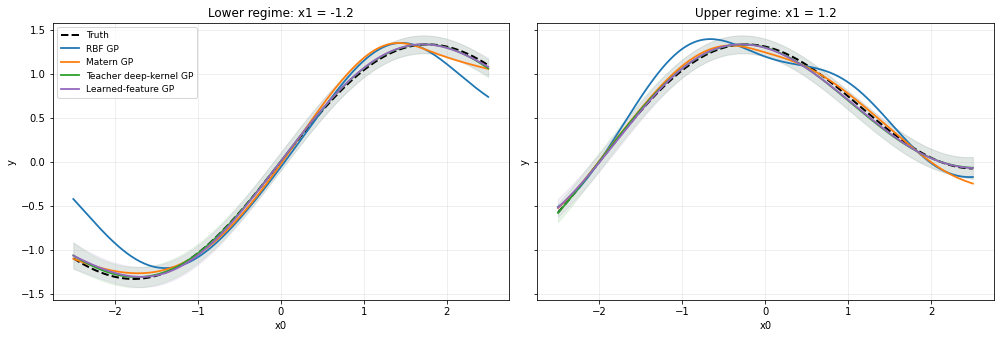

In [13]:
def predict_raw(model, X_raw):
    X_std = x_scaler.transform(X_raw)
    mean, std = model.predict(X_std, return_std=True)
    return mean, observation_std(std)

def predict_teacher(X_raw):
    feat = teacher_scaler.transform(teacher_feature(X_raw))
    mean, std = teacher_gp.predict(feat, return_std=True)
    return mean, observation_std(std)

def predict_learned(X_raw):
    feat = feature_net(torch.tensor(x_scaler.transform(X_raw), dtype=torch.float32)).detach().numpy()
    mean, std = learned_gp.predict(feat, return_std=True)
    return mean, observation_std(std)

x0_line = np.linspace(-2.5, 2.5, 300)
regimes = [(-1.2, 'Lower regime: x1 = -1.2'), (1.2, 'Upper regime: x1 = 1.2')]
colors = {
    'Truth': 'black',
    'RBF GP': 'tab:blue',
    'Matern GP': 'tab:orange',
    'Teacher deep-kernel GP': 'tab:green',
    'Learned-feature GP': 'tab:purple',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, (x1_fixed, title) in zip(axes, regimes):
    X_line = np.column_stack([x0_line, np.full_like(x0_line, x1_fixed)])
    y_line_true = target_function(X_line)

    ax.plot(x0_line, y_line_true, color=colors['Truth'], linestyle='--', linewidth=2.0, label='Truth')

    for name in ['RBF GP', 'Matern GP']:
        mean, std = predict_raw(model_store[name]['model'], X_line)
        ax.plot(x0_line, mean, color=colors[name], linewidth=1.8, label=name)

    for name, predictor in [
        ('Teacher deep-kernel GP', predict_teacher),
        ('Learned-feature GP', predict_learned),
    ]:
        mean, std = predictor(X_line)
        ax.plot(x0_line, mean, color=colors[name], linewidth=1.8, label=name)
        ax.fill_between(x0_line, mean - 1.96 * std, mean + 1.96 * std, color=colors[name], alpha=0.10)

    ax.set_title(title)
    ax.set_xlabel('x0')
    ax.set_ylabel('y')

axes[0].legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


## 7. What This Notebook Shows

### Main lesson

A deep kernel helps when the target is smooth in a **latent coordinate system**, but not in the raw coordinates seen by a standard stationary GP.

### In this notebook

- The **raw RBF GP** is the weakest baseline because it uses a single stationary geometry in raw space.
- The **raw Matern GP** is more robust, but still constrained by the same raw geometry.
- The **teacher deep-kernel GP** gives the lowest RMSE and the cleanest recovery of the hidden regime structure.
- The **learned-feature GP** recovers most of that gain once the feature map is learned.

### How to read the benchmark table

- `RMSE` is the clearest score for the representation-learning gain in this two-stage notebook.
- `ObsNLPD` and `ObsCoverage95` evaluate observation intervals after adding measurement noise back to the GP variance.
- Because the feature map is learned in a separate proxy stage here, uncertainty calibration is still not as strong as in a fully end-to-end DKL model.

### Practical interpretation

In real applied work, the unknown part is the feature map $\phi_\theta(x)$.  Deep kernel learning replaces the hand-crafted or teacher feature map with a neural network and trains it from data so that the GP sees a representation where a simple kernel is once again appropriate.

## Takeaway

On the hidden-regime 2D problem, raw-input GPs blur across the regime boundary, the teacher deep kernel restores it, and the supervised proxy reaches most of that gain. For the joint marginal-likelihood form (true DKL) see GPyTorch\u2019s `DeepKernel`; the L14 deck flags the same caveat next to the DKL diagram.


In [ ]:
# Smoke-mode validation: at least one GP variant achieves a reasonable RMSE on the benchmark.
if RUN_MODE == 'smoke':
    _best_rmse = float(comparison['RMSE'].iloc[0])
    assert _best_rmse < 1.0, f'Best benchmark RMSE too large: {_best_rmse:.3e}'
